¿Porqué una empresa podria no cmompartir sus datos reales?
¿Que riesgos existen al utilizar informacion personal de cliente?
¿Crees que es posible entrenar modelo de ML sin utilizar datos reales?

In [1]:
pip install faker

Note: you may need to restart the kernel to use updated packages.


In [2]:
from faker import Faker
import pandas as pd
import random

In [3]:
#Creamos una instancia de Faker
fake = Faker ("es_MX")

In [4]:
#Generamos datos significativos: 100 registros
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100,50000),
        "plataforma": random.choice(
            ["TikTok","Instagram","Youtube"]
        )
    })
    

In [5]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Jorge Luis Cabán Saucedo,virginia99@example.net,52,46359,Youtube
1,2,Joaquín Darío Arias Bustos,anelviera@example.net,35,43977,Instagram
2,3,Joaquín Óliver de Jesús,jperea@example.net,57,16925,Instagram
3,4,Benjamín Serafín Raya,ncastillo@example.org,46,46240,Youtube
4,5,Ramón Pulido Benavides,espartaco06@example.org,52,14392,Youtube


In [6]:
#Exploramos en dataset
df.info

<bound method DataFrame.info of      id_usuario                           nombre  \
0             1         Jorge Luis Cabán Saucedo   
1             2       Joaquín Darío Arias Bustos   
2             3          Joaquín Óliver de Jesús   
3             4            Benjamín Serafín Raya   
4             5           Ramón Pulido Benavides   
..          ...                              ...   
995         996                    Amanda Aranda   
996         997  Vanesa Lilia Bahena Castellanos   
997         998            Conchita Celia Ocampo   
998         999   Sara Carolina Arellano Jiménez   
999        1000       Ruby Adela Vásquez Velasco   

                              correo  edad  seguidores plataforma  
0             virginia99@example.net    52       46359    Youtube  
1              anelviera@example.net    35       43977  Instagram  
2                 jperea@example.net    57       16925  Instagram  
3              ncastillo@example.org    46       46240    Youtube  
4  

In [7]:
#Estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,1000,1000,NaN,NaN,3
top,NaN,Jorge Luis Cabán Saucedo,virginia99@example.net,NaN,NaN,Youtube
freq,NaN,1,1,NaN,NaN,347
mean,500.500000,NaN,NaN,41.875000,24779.108000,NaN
std,288.819436,NaN,NaN,13.910819,14369.110536,NaN
min,1.000000,NaN,NaN,18.000000,126.000000,NaN
25%,250.750000,NaN,NaN,29.000000,12423.500000,NaN
50%,500.500000,NaN,NaN,43.000000,24906.000000,NaN
75%,750.250000,NaN,NaN,53.000000,36914.750000,NaN


In [8]:
#Importar librerias para graficar 
import seaborn as sns
import matplotlib.pyplot as plt

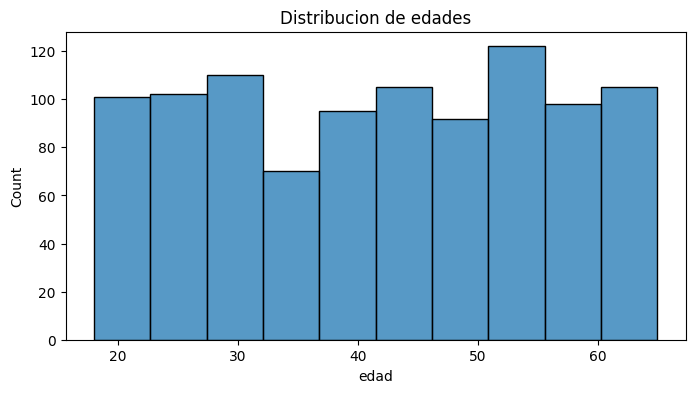

In [9]:
#Distribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()
    

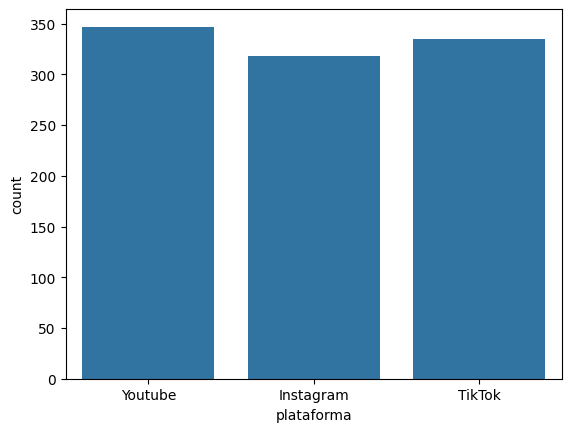

In [10]:
#Usuarios por plataforma 
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [11]:
df_sucio = df.copy()

In [12]:
#Le colocamos datos nulos
for i in random.sample(range(len(df_sucio)), 5 ):
    df_sucio.loc[i, "nombre"] = None

In [13]:
df_sucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      995 non-null    str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [14]:
#Edades invalidas
for i in random.sample(range(len(df_sucio)), 5 ):
    df_sucio.loc[i, "edad"] = -10

In [15]:
df_sucio.describe()["edad"]

count    1000.000000
mean       41.634000
std        14.359186
min       -10.000000
25%        29.000000
50%        43.000000
75%        53.000000
max        65.000000
Name: edad, dtype: float64

In [16]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)), 5 ):
    df_sucio.loc[i, "seguidores"] = 5000000

In [17]:
df_sucio.describe()["seguidores"]

count    1.000000e+03
mean     4.969463e+04
std      3.513853e+05
min      1.260000e+02
25%      1.250275e+04
50%      2.507300e+04
75%      3.721925e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [18]:
#Generamos correo invalidos
for i in random.sample(range(len(df_sucio)), 5 ):
    df_sucio.loc[i, "correo"] = "correo_invalido"

In [19]:
df_sucio.describe(include=["str", "object"])

,nombre,correo,plataforma
count,995,1000,1000
unique,995,996,3
top,Jorge Luis Cabán Saucedo,correo_invalido,Youtube
freq,1,5,347


In [20]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [ ]:
pd.set_option('display.float_format', lambda x:'%.2f

In [22]:
#Estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,995,1000,1000.000000,1.000000e+03,1000
unique,NaN,995,996,NaN,NaN,3
top,NaN,Jorge Luis Cabán Saucedo,correo_invalido,NaN,NaN,Youtube
freq,NaN,1,5,NaN,NaN,347
mean,500.500000,NaN,NaN,41.634000,4.969463e+04,NaN
std,288.819436,NaN,NaN,14.359186,3.513853e+05,NaN
min,1.000000,NaN,NaN,-10.000000,1.260000e+02,NaN
25%,250.750000,NaN,NaN,29.000000,1.250275e+04,NaN
50%,500.500000,NaN,NaN,43.000000,2.507300e+04,NaN
75%,750.250000,NaN,NaN,53.000000,3.721925e+04,NaN
